In [ ]:
import pickle
with open('/content/my_model.pickle','rb') as f:
  model = pickle.load(f)

In [ ]:
def predict_sales(x1,x2):

  from sklearn.preprocessing import PolynomialFeatures
  pol = PolynomialFeatures(2,include_bias=False)

  pol_f = pol.fit_transform([[x1,x2]])
  return model.predict(pol_f)

In [ ]:
print(predict_sales(31,41)[0][0])

9.394041935371856


In [ ]:
from math import exp
exp(-32)

1.2664165549094176e-14

#Logistic Regression

In [ ]:
import numpy as np
data = np.array([[3.87,2.65,0],
                 [2.64,3.63,0],
                 [4.93,5.50,0],
                 [2.83,2.95,0],
                 [4.07,4.00,0],
                 [8.27,3.57,1],
                 [6.36,3.09,1],
                 [7.99,2.97,1],
                 [9.76,1.42,1],
                 [8.76,4.60,1]])
print(data)

[[3.87 2.65 0.  ]
 [2.64 3.63 0.  ]
 [4.93 5.5  0.  ]
 [2.83 2.95 0.  ]
 [4.07 4.   0.  ]
 [8.27 3.57 1.  ]
 [6.36 3.09 1.  ]
 [7.99 2.97 1.  ]
 [9.76 1.42 1.  ]
 [8.76 4.6  1.  ]]


In [ ]:
from math import exp
coef = [0.55,0.45,1.10]

yhat = coef[0]
yhat += coef[1] * data[:,0:1]
yhat += coef[2] * data[:,1:2]

In [ ]:
for val in yhat:
  z = 1.0/(1.0 + exp(-val))
  print(z,round(z))

0.9945490526405021 1
0.9967666566425619 1
0.9998520517428532 1
0.9937474890241793 1
0.9988667140306183 1
0.9997250097809539 1
0.9988996214086664 1
0.9993967045277559 1
0.9985048015184993 1
0.9999289460461748 1


In [ ]:
import numpy as np
data = np.array([[3.87,2.65,0],
                 [2.64,3.63,0],
                 [4.93,5.50,0],
                 [2.83,2.95,0],
                 [4.07,4.00,0],
                 [8.27,3.57,1],
                 [6.36,3.09,1],
                 [7.99,2.97,1],
                 [9.76,1.42,1],
                 [8.76,4.60,1]])
print(data)

[[3.87 2.65 0.  ]
 [2.64 3.63 0.  ]
 [4.93 5.5  0.  ]
 [2.83 2.95 0.  ]
 [4.07 4.   0.  ]
 [8.27 3.57 1.  ]
 [6.36 3.09 1.  ]
 [7.99 2.97 1.  ]
 [9.76 1.42 1.  ]
 [8.76 4.6  1.  ]]


In [ ]:
def predict(coef,row):
  yhat = coef[0]
  for i in range(2):
    yhat += coef[i+1] * row[i]
  return 1.0/(1.0 + exp(-yhat))

In [ ]:
coef = [0.55,0.45,1.10]
for row in data:
  z = predict(coef,row)
  print('expected',row[2], 'Predicted',z , 'final',round(z))

expected 0.0 Predicted 0.9945490526405021 final 1
expected 0.0 Predicted 0.9967666566425619 final 1
expected 0.0 Predicted 0.9998520517428532 final 1
expected 0.0 Predicted 0.9937474890241793 final 1
expected 0.0 Predicted 0.9988667140306183 final 1
expected 1.0 Predicted 0.9997250097809539 final 1
expected 1.0 Predicted 0.9988996214086664 final 1
expected 1.0 Predicted 0.9993967045277559 final 1
expected 1.0 Predicted 0.9985048015184993 final 1
expected 1.0 Predicted 0.9999289460461748 final 1


In [ ]:
lr = 0.3
for epoch in range(30):
  sum_error = 0
  for row in data:
    z = predict(coef,row)
    error = row[-1] - z
    sum_error += error**2
    coef[0] = coef[0] + lr * error * z * (1-z)
    for i in range(2):
      coef[i+1] = coef[i+1] + lr * error * z * (1-z) * row[i]

  print(epoch,sum_error)

0 0.4048095175369079
1 0.39284782230414456
2 0.38163428441342123
3 0.37106038679570846
4 0.3610424255679525
5 0.3515149701084842
6 0.3424261777726784
7 0.33373440179692115
8 0.32540571103586374
9 0.31741205979836323
10 0.30972992622151563
11 0.3023392918429345
12 0.295222872050145
13 0.28836553261854203
14 0.2817538453512141
15 0.2753757483866704
16 0.269220285694725
17 0.26327740674208794
18 0.2575378120242119
19 0.25199283363733077
20 0.24663434265447284
21 0.24145467701488008
22 0.23644658510908784
23 0.23160318136375496
24 0.22691791098910066
25 0.2223845217116805
26 0.21799704082350985
27 0.21374975627067172
28 0.20963720080714765
29 0.2056541384730465


In [ ]:
print(coef)

[-0.6751166235076813, 1.4047409405986906, -2.003491377162806]


In [ ]:
for row in data:
  z = predict(coef,row)
  print('expected',row[2], 'Predicted',z , 'final',round(z))

expected 0.0 Predicted 0.36632359660927594 final 0
expected 0.0 Predicted 0.014213126502149873 final 0
expected 0.0 Predicted 0.008417858236872211 final 0
expected 0.0 Predicted 0.06849764684143254 final 0
expected 0.0 Predicted 0.04871686331868917 final 0
expected 1.0 Predicted 0.9778956109512356 final 1
expected 1.0 Predicted 0.8877784726183893 final 1
expected 1.0 Predicted 0.9900323631387293 final 1
expected 1.0 Predicted 0.9999624649253054 final 1
expected 1.0 Predicted 0.9179153151907491 final 1


#Logistic Regression Using Library

In [ ]:
import numpy as np
data = np.array([[3.87,2.65,0],
                 [2.64,3.63,0],
                 [4.93,5.50,0],
                 [2.83,2.95,0],
                 [4.07,4.00,0],
                 [8.27,3.57,1],
                 [6.36,3.09,1],
                 [7.99,2.97,1],
                 [9.76,1.42,1],
                 [8.76,4.60,1]])
print(data)

[[3.87 2.65 0.  ]
 [2.64 3.63 0.  ]
 [4.93 5.5  0.  ]
 [2.83 2.95 0.  ]
 [4.07 4.   0.  ]
 [8.27 3.57 1.  ]
 [6.36 3.09 1.  ]
 [7.99 2.97 1.  ]
 [9.76 1.42 1.  ]
 [8.76 4.6  1.  ]]


In [ ]:
X = data[:,0:2]
Y = data[:,2:]

In [ ]:
from sklearn.linear_model import LogisticRegression
lmodel = LogisticRegression()

lmodel.fit(X,Y)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
lmodel.predict(X)

array([0., 0., 0., 0., 0., 1., 1., 1., 1., 1.])

In [ ]:
lmodel.predict_proba(X)

array([[0.87927676, 0.12072324],
       [0.97866316, 0.02133684],
       [0.84527963, 0.15472037],
       [0.96629242, 0.03370758],
       [0.90174584, 0.09825416],
       [0.04556987, 0.95443013],
       [0.29155872, 0.70844128],
       [0.05155347, 0.94844653],
       [0.00365011, 0.99634989],
       [0.03641066, 0.96358934]])

#Model Evaluation Process and Logistic regression for real time data

In [ ]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer()

In [ ]:
df.keys()

dict_keys(['data', 'target', 'target_names', 'DESCR', 'feature_names', 'filename'])

In [ ]:
import pandas as pd
X = pd.DataFrame(df['data'],columns=df['feature_names'])

In [ ]:
Y = df['target']

In [ ]:
pd.DataFrame(Y)[0].value_counts()

1    357
0    212
Name: 0, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,random_state=1)

In [ ]:
df['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
from sklearn.linear_model import LogisticRegression
lmodel = LogisticRegression()

In [ ]:
lmodel.fit(xtrain,ytrain)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
ytrain_pred = lmodel.predict(xtrain)
print((ytrain_pred == ytrain).sum()/len(xtrain))

0.9460093896713615


In [ ]:
print(lmodel.score(xtrain,ytrain))
print(lmodel.score(xtest,ytest))

0.9460093896713615
0.9440559440559441


In [ ]:
ytest_pred = lmodel.predict(xtest)

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(ytrain,ytrain_pred))

[[142  15]
 [  8 261]]


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(ytest,ytest_pred))

[[51  4]
 [ 4 84]]


In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

In [ ]:
ytest_proba = lmodel.predict_proba(xtest)

In [ ]:
prob_one = ytest_proba[:,1:2]

In [ ]:
#calculate auc
roc_auc_score(ytest,prob_one)

0.9869834710743801

In [ ]:
#calculate fpr,tpr & threshold value
fpr,tpr,thresh = roc_curve(ytest,prob_one)

In [ ]:
print(fpr)
print(tpr)
print(thresh)

[0.         0.         0.         0.01818182 0.01818182 0.03636364
 0.03636364 0.05454545 0.05454545 0.10909091 0.10909091 0.14545455
 0.14545455 0.30909091 0.30909091 1.        ]
[0.         0.01136364 0.85227273 0.85227273 0.86363636 0.86363636
 0.875      0.875      0.95454545 0.95454545 0.96590909 0.96590909
 0.98863636 0.98863636 1.         1.        ]
[1.99986040e+00 9.99860398e-01 9.09331563e-01 9.08378400e-01
 9.03529835e-01 8.45449559e-01 7.97857864e-01 7.97746562e-01
 5.75183422e-01 4.06282988e-01 3.93143082e-01 3.44894797e-01
 2.03129989e-01 3.18596967e-02 2.30775351e-02 4.28616568e-21]


In [ ]:
g_value = tpr * (1 - fpr)
print(g_value)

[0.         0.01136364 0.85227273 0.83677686 0.84793388 0.8322314
 0.84318182 0.82727273 0.90247934 0.85041322 0.86053719 0.82541322
 0.84483471 0.68305785 0.69090909 0.        ]


In [ ]:
print(g_value.max())
print(g_value.argmax())

0.9024793388429753
8


In [ ]:
print(fpr[12])
print(tpr[12])
print(thresh[12])

0.14545454545454545
0.9886363636363636
0.20312998909148544


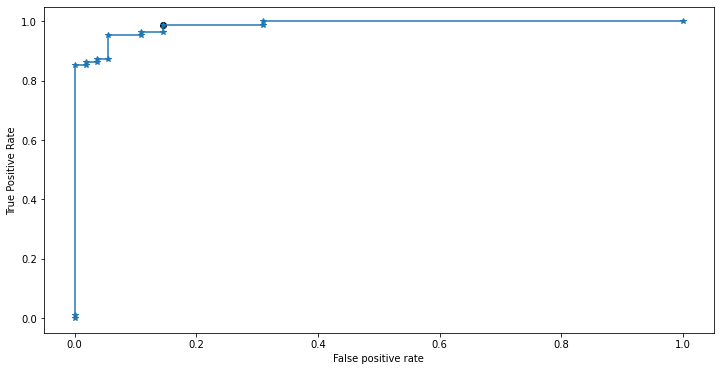

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
plt.plot(fpr,tpr,marker='*')

plt.scatter(fpr[12],tpr[12],c='black')

plt.xlabel('False positive rate')
plt.ylabel('True Positive Rate')

plt.show()

#Diabetic Data

In [139]:
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [140]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [141]:
print((df['Glucose'] == 0).sum())
print((df['BloodPressure'] == 0).sum())
print((df['BMI'] == 0).sum())

5
35
11


In [142]:
#data filtering
df[df['Glucose'] != 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [143]:
df[df['SkinThickness'] == 0]['Outcome'].value_counts()

0    139
1     88
Name: Outcome, dtype: int64

In [144]:
df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [145]:
import pandas as pd
df = pd.read_csv('/content/heart_deseases.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
